In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install datasets==2.20.0
!pip install octis==1.14.0
!pip install gensim==4.3.3
!pip install autoray==0.6.11
!pip uninstall -y jax jaxlib
!pip install jax==0.4.10 jaxlib==0.4.10 --find-links https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install pennylane==0.37.0
!pip install -U kaleido==0.2.1

  Using cached octis-1.14.0-py2.py3-none-any.whl.metadata (27 kB)
  Using cached scikit-learn-1.1.0.tar.gz (6.8 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
  Using cached jax-0.4.10.tar.gz (1.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Ignored the following yanked versions: 0.4.32
ERROR: Cou

In [2]:
import os
import re
import ast
import glob
import json
import math
import numpy as np
import pandas as pd
import plotly.express as px
from functools import reduce
from datetime import datetime

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def is_json(myjson):
  try:
    json.loads(myjson)
  except ValueError as e:
    return False
  return True

def parse_file(file):
  def parse_line(line,keys):
    res = {}
    for part in line.split(", "):
      for key in keys:
        if key in part:
          value = part.split(key)[1][int(key+":" in part):].strip()
          res[key] = float(value) if value.isnumeric() else (None if value=="None" else (json.loads(value) if is_json(value) else value))
    return res
  def parse_measure(lines):
    res = {}
    for line in lines:
      value = parse_line(line,["epoch","train loss","cv","npmi","td"])
      if "epoch" in value:
        res["epoch"] = int(value["epoch"].split("/")[0])
      res |= dict((k,v) for k,v in value.items() if k in ["train loss"])
      if "cv" in value.keys():
        res["evaluation"] =  dict((k,v) for k,v in value.items() if k in ["cv","npmi","td"])
        res["evaluation"]["quality"] = float('%.6f'%(res["evaluation"]["cv"]*res["evaluation"]["td"]))
    return res
  res = {"metadata":{},"payload":[]}
  with open(file,"r") as f:
    lines = []
    for line in f.readlines():
      line = line.lower()
      last_line = None
      detected = []
      while line!=last_line:
        last_line = line
        m = re.search("(\[[^]]+\])",reduce(lambda acc,x: acc.replace(x,"*"*len(x)),detected,line))
        if m:
          for value in m.groups():
            detected.append(value.replace(", ",","))
            line = line.replace(value,value.replace(", ",","))
      res["metadata"] |= parse_line(line,["start training","end training","model","pretrained model","quantum circuit","dataset","batch","gpu"])
      if "epoch" in line:
        if not lines or lines[-1].split(",")[0] in line:
          lines.append(line)
        elif lines:
          res["payload"].append(parse_measure(lines))
          lines = [line]
    if lines:
      res["payload"].append(parse_measure(lines))
  start = datetime.fromisoformat(res["metadata"]["start training"])
  if "end training" not in res["metadata"]:
    print("End Training not found",file)
    return None
  end = datetime.fromisoformat(res["metadata"]["end training"])
  res["metadata"]["duration"] = math.ceil((end - start).total_seconds()/60)
  return res

def parse_files(path):
  res = {}
  regex = "([\S\s]+)".join(re.escape(p) for p in path.split("*"))
  files = glob.glob(path)
  for file in files:
    m = re.search(regex,file)
    tmp = res
    groups = m.groups()
    for i,key in enumerate(groups[:-1]):
      if i==len(groups)-2:
        value = parse_file(file)
        if value:
          tmp[key] = value
      else:
        if key in tmp:
          tmp = tmp[key]
        else:
          tmp[key] = {}
          tmp = tmp[key]

  return res

ag_news_res = parse_files("/content/drive/MyDrive/master/ntm/ag_news/*/runs/*/*.txt")
twenty_news_res = parse_files("/content/drive/MyDrive/master/ntm/twenty_news/*/runs/*/*.txt")

In [5]:
for model in ag_news_res.keys():
  print(model)
  for run,values in sorted(ag_news_res[model].items(),key=lambda x: int(x[0])):
    x1 = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
    x2 = sorted(values["payload"],key=lambda x: (x["evaluation"]["cv"]+x["evaluation"]["td"],-x["epoch"]),reverse=True)[0]
    print("*" if x1["epoch"]!=x2["epoch"] else "",run,":", x1["epoch"],x2["epoch"],"...................",x1["evaluation"]["quality"],"          |      ",x2["evaluation"]["cv"]+x2["evaluation"]["td"])

hybrid vae prob
 1 : 12 12 ................... 0.601335           |       1.5885
 2 : 7 7 ................... 0.630008           |       1.6215
 3 : 6 6 ................... 0.577412           |       1.5645
 4 : 3 3 ................... 0.669845           |       1.6551
 5 : 7 7 ................... 0.65142           |       1.633
classical vae
 1 : 18 18 ................... 0.639153           |       1.6194
 2 : 7 7 ................... 0.681782           |       1.6667
 3 : 18 18 ................... 0.615536           |       1.5854
 4 : 20 20 ................... 0.64543           |       1.6294
 5 : 12 12 ................... 0.684647           |       1.6666
classical vae prob
 1 : 1 1 ................... 0.572418           |       1.5435
 2 : 1 1 ................... 0.5985           |       1.565
 3 : 1 1 ................... 0.601258           |       1.579
 4 : 3 3 ................... 0.642722           |       1.6289
 5 : 1 1 ................... 0.568054           |       1.5277
hyb

In [6]:
for model in twenty_news_res.keys():
  print(model)
  for run,values in sorted(twenty_news_res[model].items(),key=lambda x: int(x[0])):
    x1 = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
    x2 = sorted(values["payload"],key=lambda x: (x["evaluation"]["cv"]+x["evaluation"]["td"],-x["epoch"]),reverse=True)[0]
    print("*" if x1["epoch"]!=x2["epoch"] else "",run,":", x1["epoch"],x2["epoch"],"...................",x1["evaluation"]["quality"],"          |      ",x2["evaluation"]["cv"]+x2["evaluation"]["td"])

hybrid vae prob
 1 : 10 10 ................... 0.625396           |       1.5823
 2 : 13 13 ................... 0.594224           |       1.5449
 3 : 15 15 ................... 0.593151           |       1.5440999999999998
 4 : 14 14 ................... 0.619675           |       1.5764
 5 : 18 18 ................... 0.569083           |       1.5137
classical vae prob
 1 : 5 5 ................... 0.541644           |       1.4742000000000002
 2 : 15 15 ................... 0.54763           |       1.4886
 3 : 14 14 ................... 0.531623           |       1.4670999999999998
 4 : 16 16 ................... 0.624665           |       1.5849
 5 : 17 17 ................... 0.565618           |       1.5101
hybrid vae
 1 : 15 15 ................... 0.566269           |       1.5118999999999998
 2 : 11 11 ................... 0.59747           |       1.5478
 3 : 17 17 ................... 0.619718           |       1.5788
 4 : 20 20 ................... 0.57953           |       1.5322
 

In [ ]:
ONLY_EPOCHS = [1,3,5,10,20]
def extract_data(data):
  data = dict((k,v) for k,v in data.items() if len(v)>=1)
  results = {}
  #print("Runtime:",{k:np.median([run["metadata"]["duration"] for run in v.values()]) for k,v in data.items()})
  for model,measures in data.items():
    tmp = {}
    for run,measure in measures.items():
        tmp[run] = {epoch:None for epoch in ONLY_EPOCHS}
        for epoch in ONLY_EPOCHS:
          m = sorted([m for m in measure["payload"] if m["epoch"]<=epoch],key=lambda m:m["evaluation"]["quality"],reverse=True)[0]
          tmp[run][epoch] = m["evaluation"]["quality"]
    results[model] = tmp
  return results

def extract_diffs(data,combinations):
  results = {}
  def diffs(qi_runs,runs):
    res = {}
    for run in range(1,6):
      run = str(run)
      res[run] = {}
      for epoch in ONLY_EPOCHS:
        res[run][epoch] = qi_runs[run][epoch] - runs[run][epoch]
    return res
  def medians(lr_diffs):
    res = {}
    for epoch in ONLY_EPOCHS:
      data = np.array([lr_diff[epoch] for lr_diff in lr_diffs.values()])
      res[epoch] = np.median(data)
    return res
  for combination in combinations:
    results[combination] = medians(diffs(data[combination[0]],data[combination[1]]))
  return results

for model in ["hybrid vae","hybrid vae prob"]:
  results = extract_data(ag_news_res)
  diffs = extract_diffs(results,[(model,"classical vae"),(model,"classical vae prob")])
  lines = [[("\\textbf{"+str(float('%.2f'%(values[epoch]*100)))+"}") if epoch in [3,20] else str(float('%.2f'%(values[epoch]*100))) for epoch in ONLY_EPOCHS ] for values in diffs.values()]
  line = [str(e) for line in lines for e in line]
  print(model+" & "+" & ".join(line)+"\\\\")
  print("\\hline")

hybrid vae & 10.29 & \textbf{6.86} & 5.13 & 2.03 & \textbf{1.32} & -0.08 & \textbf{7.0} & 7.0 & 7.9 & \textbf{7.9}\\
\hline
hybrid vae prob & -7.42 & \textbf{-0.98} & -2.14 & -2.05 & \textbf{-3.78} & -11.97 & \textbf{0.81} & 1.28 & 2.71 & \textbf{2.89}\\
\hline


In [ ]:
for model in ["hybrid vae","hybrid vae prob"]:
  results = extract_data(twenty_news_res)
  diffs = extract_diffs(results,[(model,"classical vae"),(model,"classical vae prob")])
  lines = [[("\\textbf{"+str(float('%.2f'%(values[epoch]*100)))+"}") if epoch in [3,20] else str(float('%.2f'%(values[epoch]*100))) for epoch in ONLY_EPOCHS ] for values in diffs.values()]
  line = [str(e) for line in lines for e in line]
  print(model+" & "+" & ".join(line)+"\\\\")
  print("\\hline")

hybrid vae & -5.43 & \textbf{-3.13} & -4.26 & -1.4 & \textbf{-0.89} & -6.63 & \textbf{-5.23} & -0.28 & 2.89 & \textbf{2.6}\\
\hline
hybrid vae prob & -2.24 & \textbf{-4.29} & -4.81 & 3.39 & \textbf{-0.14} & -4.19 & \textbf{-3.73} & -2.09 & 4.13 & \textbf{4.66}\\
\hline


In [7]:
ag_news_res.keys()
m_n = lambda x: x.replace("hybrid","Hybrid").replace("classical","Classical").replace("vae","VAE")

In [ ]:
import plotly.graph_objects as go
import numpy as np


avg_std_qualities = {}
for model in sorted(ag_news_res.keys()):
  for run,values in sorted(ag_news_res[model].items(),key=lambda x: int(x[0])):
        x1 = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        if model not in avg_std_qualities:
          avg_std_qualities[model] = values
          continue
        x2 = sorted(avg_std_qualities[model]["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        if x1["evaluation"]["quality"]>x2["evaluation"]["quality"]:
          avg_std_qualities[model] = values

fig = go.Figure()
for model,values in avg_std_qualities.items():
  values = {"payload":sorted(values["payload"],key=lambda x: x["epoch"])}
  fig.add_trace(go.Scatter(x=[x["epoch"] for x in values["payload"]], y=[x["evaluation"]["quality"] for x in values["payload"]],
                      mode='lines+markers',
                      name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)") ))

fig.update_layout(
    plot_bgcolor='white',
    xaxis_title="Epoch", yaxis_title="Quality",
    autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
)
fig.update_xaxes(linecolor='grey', mirror = True)
fig.update_yaxes(linecolor='grey', mirror = True)
fig.show()
fig.write_image('training-peak-quality-agnews.pdf', engine="kaleido", width=800, height=500)

In [ ]:
import plotly.graph_objects as go
import numpy as np


avg_std_qualities = {}
for model in sorted(twenty_news_res.keys()):
  for run,values in sorted(twenty_news_res[model].items(),key=lambda x: int(x[0])):
        x1 = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        if model not in avg_std_qualities:
          avg_std_qualities[model] = values
          continue
        x2 = sorted(avg_std_qualities[model]["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        if x1["evaluation"]["quality"]>x2["evaluation"]["quality"]:
          avg_std_qualities[model] = values


fig = go.Figure()
for model,values in avg_std_qualities.items():
  values = {"payload":sorted(values["payload"],key=lambda x: x["epoch"])}
  fig.add_trace(go.Scatter(x=[x["epoch"] for x in values["payload"]], y=[x["evaluation"]["quality"] for x in values["payload"]],
                      mode='lines+markers',
                      name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)") ))

fig.update_layout(
    plot_bgcolor='white',
    xaxis_title="Epoch", yaxis_title="Quality",
    autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
)
fig.update_xaxes(linecolor='grey', mirror = True)
fig.update_yaxes(linecolor='grey', mirror = True)
fig.show()
fig.write_image('training-peak-quality-20news.pdf', engine="kaleido", width=800, height=500)

In [ ]:
import plotly.express as px
import pandas as pd
peak_qualities = {}
for model in sorted(ag_news_res.keys()):
  peak_qualities[model] = []
  for run,values in sorted(ag_news_res[model].items(),key=lambda x: int(x[0])):
        x = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        peak_qualities[model].append(x["evaluation"]["quality"])

df = pd.DataFrame({"Model":[m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)")  for model,qualities in peak_qualities.items() for _ in qualities],
                   "Quality":[quality for _,qualities in peak_qualities.items() for quality in qualities],
                   "Flavor":["LLS" if "prob" in model else "SLS"  for model,qualities in peak_qualities.items() for _ in qualities]
                   })
fig = px.box(df, x="Model", y="Quality", color="Flavor")#, points="all"
fig.update_layout(
    plot_bgcolor='white',
    autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
)
fig.update_xaxes(linecolor='grey', mirror = True)
fig.update_yaxes(linecolor='grey', mirror = True)
fig.show()
fig.write_image('boxplot-quality-agnews.pdf', engine="kaleido", width=800, height=500)

In [ ]:
import plotly.express as px
import pandas as pd
peak_qualities = {}
for model in sorted(twenty_news_res.keys()):
  peak_qualities[model] = []
  for run,values in sorted(twenty_news_res[model].items(),key=lambda x: int(x[0])):
        x = sorted(values["payload"],key=lambda x: (x["evaluation"]["quality"],-x["epoch"]),reverse=True)[0]
        peak_qualities[model].append(x["evaluation"]["quality"])

df = pd.DataFrame({"Model":[m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)")  for model,qualities in peak_qualities.items() for _ in qualities],
                   "Quality":[quality for _,qualities in peak_qualities.items() for quality in qualities],
                   "Flavor":["LLS" if "prob" in model else "SLS"  for model,qualities in peak_qualities.items() for _ in qualities]
                   })
fig = px.box(df, x="Model", y="Quality", color="Flavor")#, points="all"
fig.update_layout(
    plot_bgcolor='white',
    autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
)
fig.update_xaxes(linecolor='grey', mirror = True)
fig.update_yaxes(linecolor='grey', mirror = True)

#fig.update_xaxes(showline=True, linewidth=1.2, linecolor='black', mirror = True, ticks='outside', tickfont_size=16, tickfont_family='Arial', tick0=0, dtick=25)
#fig.update_yaxes(showline=True, linewidth=1.2, linecolor='black', mirror = True, ticks='outside', tickfont_size=16, tickfont_family='Arial', tick0=-0.20, dtick=0.05)
fig.show()
fig.write_image('boxplot-quality-20news.pdf', engine="kaleido", width=800, height=500)

In [ ]:
import plotly.express as px
import pandas as pd
for metric in ["quality","cv","npmi","td"]:
  titles = {"quality":"Quality","cv":"C_v","npmi":"NPMI","td":"TD"}
  print("& \\multicolumn{4}{c}{\\textbf{Sorted by "+titles[metric]+"}} \\\\")
  avg_std_peak_qualities = {}
  for model in sorted(ag_news_res.keys()):
    avg_std_peak_qualities[model] = []
    for run,values in sorted(ag_news_res[model].items(),key=lambda x: int(x[0])):
          x = sorted(values["payload"],key=lambda x: (x["evaluation"][metric],-x["epoch"]),reverse=True)[0]
          avg_std_peak_qualities[model].append(x)

  for model,xs in avg_std_peak_qualities.items():
    m = lambda key: str(float("%.4f"%round(np.mean([x["evaluation"][key] for x in xs]),2)))+"$\\pm$"+str(float("%.4f"%round(np.std([x["evaluation"][key] for x in xs]),2)))
    print(m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)")+" & "+m("quality")+" & "+m("cv")+" & "+m("npmi")+" & "+m("td")+"\\\\")
    print("\\hline")

& \multicolumn{4}{c}{\textbf{Sorted by Quality}} \\
Classical VAE (SLS) & 0.65$\pm$0.03 & 0.7$\pm$0.02 & 0.19$\pm$0.02 & 0.93$\pm$0.02\\
\hline
Classical VAE (LLS) & 0.6$\pm$0.03 & 0.65$\pm$0.02 & 0.15$\pm$0.01 & 0.92$\pm$0.03\\
\hline
Hybrid VAE (SLS) & 0.67$\pm$0.02 & 0.71$\pm$0.02 & 0.2$\pm$0.01 & 0.95$\pm$0.0\\
\hline
Hybrid VAE (LLS) & 0.63$\pm$0.03 & 0.65$\pm$0.04 & 0.16$\pm$0.03 & 0.96$\pm$0.01\\
\hline
& \multicolumn{4}{c}{\textbf{Sorted by C_v}} \\
Classical VAE (SLS) & 0.65$\pm$0.03 & 0.7$\pm$0.02 & 0.19$\pm$0.02 & 0.93$\pm$0.02\\
\hline
Classical VAE (LLS) & 0.6$\pm$0.03 & 0.65$\pm$0.02 & 0.15$\pm$0.01 & 0.92$\pm$0.03\\
\hline
Hybrid VAE (SLS) & 0.66$\pm$0.02 & 0.71$\pm$0.02 & 0.2$\pm$0.02 & 0.93$\pm$0.02\\
\hline
Hybrid VAE (LLS) & 0.6$\pm$0.04 & 0.66$\pm$0.04 & 0.17$\pm$0.03 & 0.91$\pm$0.05\\
\hline
& \multicolumn{4}{c}{\textbf{Sorted by NPMI}} \\
Classical VAE (SLS) & 0.65$\pm$0.03 & 0.7$\pm$0.02 & 0.19$\pm$0.02 & 0.93$\pm$0.02\\
\hline
Classical VAE (LLS) & 0.59$\pm$0.02

In [ ]:
import plotly.express as px
import pandas as pd
for metric in ["quality","cv","npmi","td"]:
  titles = {"quality":"Quality","cv":"C_v","npmi":"NPMI","td":"TD"}
  print("& \\multicolumn{4}{|c}{\\textbf{Sorted by "+titles[metric]+"}} \\\\")
  avg_std_peak_qualities = {}
  for model in sorted(twenty_news_res.keys()):
    avg_std_peak_qualities[model] = []
    for run,values in sorted(twenty_news_res[model].items(),key=lambda x: int(x[0])):
          x = sorted(values["payload"],key=lambda x: (x["evaluation"][metric],-x["epoch"]),reverse=True)[0]
          avg_std_peak_qualities[model].append(x)

  for model,xs in avg_std_peak_qualities.items():
    m = lambda key: str(float("%.4f"%round(np.mean([x["evaluation"][key] for x in xs]),2)))+"$\\pm$"+str(float("%.4f"%round(np.std([x["evaluation"][key] for x in xs]),2)))
    #m = lambda key: str(float("%.4f"%np.mean([x["evaluation"][key] for x in xs])))+"$\pm$"+str(float("%.4f"%np.std([x["evaluation"][key] for x in xs])))
    print(m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)")+" & "+m("quality")+" & "+m("cv")+" & "+m("npmi")+" & "+m("td")+"\\\\")
    print("\\hline")

& \multicolumn{4}{|c}{\textbf{Sorted by Quality}} \\
Classical VAE (SLS) & 0.61$\pm$0.02 & 0.72$\pm$0.02 & 0.15$\pm$0.01 & 0.84$\pm$0.01\\
\hline
Classical VAE (LLS) & 0.56$\pm$0.03 & 0.69$\pm$0.03 & 0.14$\pm$0.02 & 0.82$\pm$0.02\\
\hline
Hybrid VAE (SLS) & 0.59$\pm$0.02 & 0.71$\pm$0.02 & 0.15$\pm$0.01 & 0.83$\pm$0.02\\
\hline
Hybrid VAE (LLS) & 0.6$\pm$0.02 & 0.73$\pm$0.03 & 0.16$\pm$0.01 & 0.82$\pm$0.01\\
\hline
& \multicolumn{4}{|c}{\textbf{Sorted by C_v}} \\
Classical VAE (SLS) & 0.6$\pm$0.02 & 0.73$\pm$0.02 & 0.16$\pm$0.01 & 0.83$\pm$0.02\\
\hline
Classical VAE (LLS) & 0.56$\pm$0.04 & 0.69$\pm$0.03 & 0.14$\pm$0.02 & 0.81$\pm$0.02\\
\hline
Hybrid VAE (SLS) & 0.59$\pm$0.02 & 0.72$\pm$0.02 & 0.15$\pm$0.01 & 0.82$\pm$0.01\\
\hline
Hybrid VAE (LLS) & 0.58$\pm$0.02 & 0.73$\pm$0.02 & 0.16$\pm$0.01 & 0.8$\pm$0.02\\
\hline
& \multicolumn{4}{|c}{\textbf{Sorted by NPMI}} \\
Classical VAE (SLS) & 0.6$\pm$0.02 & 0.72$\pm$0.02 & 0.16$\pm$0.01 & 0.82$\pm$0.02\\
\hline
Classical VAE (LLS) & 0.55$

In [ ]:
import plotly.graph_objects as go
import numpy as np


import plotly.express as px
import pandas as pd

def plot_mean_std_agnews(metric):
  avg_std_qualities = {}
  for model in sorted(ag_news_res.keys()):
    avg_std_qualities[model] = {}
    for run,values in sorted(ag_news_res[model].items(),key=lambda x: int(x[0])):
          assert len(values["payload"])==20
          for epoch in range(1,21):
            x = [x for x in values["payload"] if x["epoch"]==epoch][0]
            avg_std_qualities[model][epoch] = avg_std_qualities[model].get(epoch,[]) + [x["evaluation"][metric]]


  fig = go.Figure()
  line_colors = ["rgb(99, 110, 250)","rgb(239, 85, 59)","rgb(0, 204, 150)","rgb(171, 99, 250)"]
  fill_colors = ["rgba(99, 110, 250, 0.2)","rgba(239, 85, 59, 0.2)","rgba(0, 204, 150, 0.2)","rgba(171, 99, 250, 0.2)"]
  for i,model in enumerate(avg_std_qualities.keys()):
    xs = sorted(avg_std_qualities[model].items(),key=lambda x: x[0])

    x = [epoch for epoch,_ in xs]
    x_rev = x[::-1]
    y = [np.mean(qualities) for _,qualities in xs]
    y_upper = [np.mean(qualities)+np.std(qualities) for _,qualities in xs]
    y_lower = [np.mean(qualities)-np.std(qualities) for _,qualities in xs]
    y_lower = y_lower[::-1]
    fig.add_trace(go.Scatter(
        x=x+x_rev,
        y=y_upper+y_lower,
        fill='toself',
        fillcolor=fill_colors[i],
        line_color='rgba(255,255,255,0)',
        name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)"),
        showlegend=False,
    ))
    fig.add_trace(go.Scatter(
        x=x, y=y,
        line_color=line_colors[i],
        name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)"),
    ))

  fig.update_traces(mode='lines+markers')

  fig.update_layout(
      plot_bgcolor='white',
      xaxis_title="Epoch", yaxis_title=({"cv":"CV","td":"TD","quality":"Quality"})[metric],
      autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
  )
  fig.update_xaxes(linecolor='grey', mirror = True)
  fig.update_yaxes(linecolor='grey', mirror = True)
  fig.show()
  fig.write_image(f"mean-std-{metric}-over-epochs-agnews.pdf", engine="kaleido", width=800, height=500)
plot_mean_std_agnews("quality")
plot_mean_std_agnews("cv")
plot_mean_std_agnews("td")

In [ ]:
import plotly.graph_objects as go
import numpy as np


import plotly.express as px
import pandas as pd

def plot_mean_std_20news(metric):
  avg_std_qualities = {}
  for model in sorted(twenty_news_res.keys()):
    avg_std_qualities[model] = {}
    for run,values in sorted(twenty_news_res[model].items(),key=lambda x: int(x[0])):
          assert len(values["payload"])==20
          for epoch in range(1,21):
            x = [x for x in values["payload"] if x["epoch"]==epoch][0]
            avg_std_qualities[model][epoch] = avg_std_qualities[model].get(epoch,[]) + [x["evaluation"][metric]]


  fig = go.Figure()
  line_colors = ["rgb(99, 110, 250)","rgb(239, 85, 59)","rgb(0, 204, 150)","rgb(171, 99, 250)"]
  fill_colors = ["rgba(99, 110, 250, 0.2)","rgba(239, 85, 59, 0.2)","rgba(0, 204, 150, 0.2)","rgba(171, 99, 250, 0.2)"]
  for i,model in enumerate(avg_std_qualities.keys()):
    xs = sorted(avg_std_qualities[model].items(),key=lambda x: x[0])

    x = [epoch for epoch,_ in xs]
    x_rev = x[::-1]
    y = [np.mean(qualities) for _,qualities in xs]
    y_upper = [np.mean(qualities)+np.std(qualities) for _,qualities in xs]
    y_lower = [np.mean(qualities)-np.std(qualities) for _,qualities in xs]
    y_lower = y_lower[::-1]
    fig.add_trace(go.Scatter(
        x=x+x_rev,
        y=y_upper+y_lower,
        fill='toself',
        fillcolor=fill_colors[i],
        line_color='rgba(255,255,255,0)',
        name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)"),
        showlegend=False,
    ))
    fig.add_trace(go.Scatter(
        x=x, y=y,
        line_color=line_colors[i],
        name=m_n(model[:-4]+"(LLS)" if "prob" in model else model+" (SLS)"),
    ))

  fig.update_traces(mode='lines+markers')

  fig.update_layout(
      plot_bgcolor='white',
      xaxis_title="Epoch", yaxis_title=({"cv":"CV","td":"TD","quality":"Quality"})[metric],
      autosize=True, margin={'l': 40, 'r': 36,'t':15,'b':6}
  )
  fig.update_xaxes(linecolor='grey', mirror = True)
  fig.update_yaxes(linecolor='grey', mirror = True)
  fig.show()
  fig.write_image(f"mean-std-{metric}-over-epochs-20news.pdf", engine="kaleido", width=800, height=500)
plot_mean_std_20news("quality")
plot_mean_std_20news("cv")
plot_mean_std_20news("td")

In [9]:
"""
* ==============================================
* All credit to https://github.com/xuweijieshuai/Neural-Topic-Modeling-vmf/blob/main/src/topicmodeling/preprocess.py
* ==============================================
"""
from collections import defaultdict
import multiprocessing
from multiprocessing import Pool
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import numpy as np
import pandas as pd
import string

class TextProcessor:

    def __init__(self, data,all):
        self.all = all
        self.data = data
        self.bow = None
        self.word_to_index = None
        self.index_to_word = None
        self.lemmatized_sentences = None
        nltk.download('punkt')
        nltk.download('wordnet')
        nltk.download('averaged_perceptron_tagger')
        nltk.download('stopwords')

    def __str__(self):
        """String representation of TextProcessor"""
        return f'TextProcessor(len(data)={len(self.data)})'


    def get_wordnet_pos(self, word):
        tag = pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}

        return tag_dict.get(tag, wordnet.NOUN)

    def convert_to_bag_of_words(self, list_of_lists, min_freq=10, max_freq_ratio=0.05):
        if self.all:
          min_freq = 0
          max_freq_ratio=1
        # Your existing implementation here
        word_freq = defaultdict(int)
        for lst in list_of_lists:
            for word in lst:
                word_freq[word] += 1
        max_freq = len(list_of_lists) * max_freq_ratio
        vocabulary = {word for word, count in word_freq.items() if min_freq <= count < max_freq}
        word_to_index = {word: i for i, word in enumerate(vocabulary)}
        index_to_word = {i: word for word, i in word_to_index.items()}
        num_lists = len(list_of_lists)
        vocab_size = len(vocabulary)
        bag_of_words = [[0] * vocab_size for _ in range(num_lists)]
        self.lemmas = []
        for i, lst in enumerate(list_of_lists):
            lemma = []
            for word in lst:
                lemma = [word for word in lst if word in word_to_index]
                if word in word_to_index:
                    index = word_to_index[word]
                    bag_of_words[i][index] += 1

            self.lemmas.append(lemma)

        self.bow, self.word_to_index, self.index_to_word = bag_of_words, word_to_index, index_to_word

    def worker(self, data_chunk):
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))
        table = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
        lemmatized_chunk = []

        for sentence in data_chunk:
            sentence = sentence.translate(table).lower().replace("  ", " ")
            words = word_tokenize(sentence)
            lemmatized_words = [lemmatizer.lemmatize(word, self.get_wordnet_pos(word)) for word in words if word not in stop_words and lemmatizer.lemmatize(word, self.get_wordnet_pos(word)) != '' ]
            lemmatized_words = [i for i in lemmatized_words if len(i) >= 3 and (not i.isdigit()) and ' ' not in i]
            lemmatized_chunk.append(lemmatized_words)

        return lemmatized_chunk

    def lemmatize_sentences(self):
        num_processes = multiprocessing.cpu_count()
        pool = Pool(num_processes)
        data_chunks = np.array_split(self.data, num_processes)
        results = pool.map(self.worker, data_chunks)
        pool.close()
        pool.join()
        self.lemmatized_sentences = [j for i in results for j in i]

    def process(self):
        self.lemmatize_sentences()
        self.convert_to_bag_of_words(self.lemmatized_sentences)


In [10]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

from random import randint
from datasets import load_dataset
df = load_dataset('xwjzds/ag_news')
ag_news = {}
CLASSES = [0,1,2,3]
samples = dict((c,[randint(1,30000) for _ in range(10)]) for c in CLASSES)
counters = {}
for text,label in zip(df['train']['text'],df['train']['label']):
  counters[label] = counters.get(label,0) + 1
  if counters[label] in samples[label]:
    ag_news[label] = ag_news.get(label,[]) + [text]
for key in ag_news.keys():
  ag_news[key] = TextProcessor(ag_news[key],True)
  ag_news[key].process()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloa

In [17]:
MODELS = {
    "classical vae":"classical-vae-5-0.684647#12",
    "classical vae prob":"classical-vae-(prob)-4-0.642722#3",
    "hybrid vae":"hybrid-vae-2-0.694973#8",
    "hybrid vae prob":"hybrid-vae-(prob)-4-0.669845#3"
    }
def load_model(model_class,model_name):
  model_path = f"/content/drive/MyDrive/master/ntm/{model_name}.pth"
  checkpoint = torch.load(model_path,map_location=torch.device('cpu'),weights_only=False)
  vocab = checkpoint["vocab"]
  model = model_class(vocab)
  model.load_state_dict(checkpoint['model_state_dict'])
  return model,vocab

TOPIC_COUNT = 20

In [16]:
from torch.nn import functional as F
from torch import nn
import numpy as np
import gensim
import torch


class ClassicalVAESLS(nn.Module):
    def __init__(self,vocab):
        super(ClassicalVAESLS, self).__init__()

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = nn.Linear(1024, 10)
        self.encoder_fc10_logvar = nn.Linear(1024, 10)
        self.gsm_fc = nn.Linear(10, TOPIC_COUNT)

        self.bn_mu =  nn.BatchNorm1d(
            10, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            10, affine=False
        )

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))
        return self.bn_mu(F.tanh(self.encoder_fc10_mu(batch))),self.bn_log_var(F.tanh(self.encoder_fc10_logvar(batch)))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: classical vae, Pretrained Model: glove-wiki-gigaword-300"


In [15]:
from torch.nn import functional as F
from torch import nn
import numpy as np
import gensim
import torch

class ClassicalVAELLS(nn.Module):
    def __init__(self,vocab):
        super(ClassicalVAELLS, self).__init__()

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = nn.Linear(1024, 32)
        self.encoder_fc10_logvar = nn.Linear(1024, 32)
        self.gsm_fc = nn.Linear(32, TOPIC_COUNT)

        self.bn_mu =  nn.BatchNorm1d(
            32, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            32, affine=False
        )

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))
        return self.bn_mu(F.tanh(self.encoder_fc10_mu(batch))),self.bn_log_var(F.tanh(self.encoder_fc10_logvar(batch)))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: classical vae (prob), Pretrained Model: glove-wiki-gigaword-300"

In [14]:
from torch.nn import functional as F
import pennylane as qml
from torch import nn
import numpy as np
import gensim
import torch


class HybridVAESLS(nn.Module):
    def __init__(self,vocab):
        super(HybridVAESLS, self).__init__()

        WIRES = 10
        dev = qml.device('default.qubit', wires=WIRES)
        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            qml.templates.AmplitudeEmbedding(features=inputs, wires=range(WIRES), normalize=True)
            qml.templates.StronglyEntanglingLayers(weights, wires=range(WIRES))
            return [qml.expval(op=qml.PauliZ(j)) for j in range(WIRES)]

        circuit_weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=WIRES)}

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.encoder_fc10_logvar = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.gsm_fc = nn.Linear(10, TOPIC_COUNT)

        self.mu_alpha = nn.Parameter(torch.randn(10))
        self.log_var_alpha = nn.Parameter(torch.randn(10))

        self.bn_mu =  nn.BatchNorm1d(
            10, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            10, affine=False
        )

        self.temperature = nn.Parameter(torch.randn(1).squeeze())

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))

        return self.bn_mu(self.mu_alpha*self.encoder_fc10_mu(batch)),self.bn_log_var(self.log_var_alpha*self.encoder_fc10_logvar(batch))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.temperature*self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: hybrid vae, Pretrained Model: glove-wiki-gigaword-300, Quantum Circuit: AE->SEL->SEL->SEL-><Z>"

In [13]:
from torch.nn import functional as F
import pennylane as qml
from torch import nn
import numpy as np
import gensim
import torch


class HybridVAELLS(nn.Module):
    def __init__(self,vocab):
        super(HybridVAELLS, self).__init__()

        WIRES = 10
        dev = qml.device('default.qubit', wires=WIRES)
        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            qml.templates.AmplitudeEmbedding(features=inputs, wires=range(WIRES), normalize=True)
            qml.templates.StronglyEntanglingLayers(weights, wires=range(WIRES))
            return qml.probs(wires=[5,6,7,8,9])

        circuit_weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=WIRES)}

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.encoder_fc10_logvar = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.gsm_fc = nn.Linear(32, TOPIC_COUNT)

        self.mu_alpha = nn.Parameter(torch.randn(32))
        self.log_var_alpha = nn.Parameter(torch.randn(32))

        self.bn_mu =  nn.BatchNorm1d(
            32, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            32, affine=False
        )

        self.temperature = nn.Parameter(torch.randn(1).squeeze())

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))

        return self.bn_mu(self.mu_alpha*self.encoder_fc10_mu(batch)),self.bn_log_var(self.log_var_alpha*self.encoder_fc10_logvar(batch))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.temperature*self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: hybrid vae (prob), Pretrained Model: glove-wiki-gigaword-300, Quantum Circuit: AE->SEL->SEL->SEL->Prob"

In [12]:
def sample_topic_embeddings(model,vocab,doc_idx):
  model.eval()      # disables dropout
  with torch.no_grad():
    embeddings = {}
    vocab_idx = {word:i for i,word in enumerate(vocab)}
    for label,tp in ag_news.items():
      batch = torch.tensor([[bow[tp.word_to_index[word]] if word in tp.word_to_index else 0 for j,word in enumerate(vocab)] for i,bow in enumerate(tp.bow) if doc_idx==i]+[[0 for _ in range(len(vocab))]]).float()
      mu,log_var = model.encode(batch)
      for _ in range(1000):
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = model.gsm(eta)
        embeddings[label] = embeddings.get(label,[]) + [z[0].cpu().detach().tolist()]
    return embeddings

In [14]:
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE


def compute_2d_embeddings(embeddings, title):

    X = [bow for bows in embeddings.values() for bow in bows]

    tsne = TSNE(n_components=2,
              init='pca',
                random_state=42,
                #perplexity=50,
              #learning_rate=300,
              #n_iter=1600,
              verbose=1)
    components = tsne.fit_transform(X)


    fig = px.scatter(
        x=components[:, 0],
        y=components[:, 1],
        color=[label for label,bows in embeddings.items() for _ in bows],
        title=title
    )

    fig.update_layout(
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.05
        )
    )

    fig.show()

def plot_2d_tsne(model_classes,docs_idx):
  tsne = TSNE(n_components=2,
            init='pca',
              random_state=42,
              #perplexity=50,
            #learning_rate=300,
            #n_iter=1600,
            verbose=1)
  data = {"x":[],"y":[],"Class":[],"Model":[],"ID":[]}
  for doc_idx in docs_idx:
    for model_label,model_name in MODELS.items():
        model,vocab = load_model(model_classes[model_label],model_name)
        embeddings = sample_topic_embeddings(model,vocab,doc_idx)
        components = tsne.fit_transform(np.array([bow for bows in embeddings.values() for bow in bows]))
        data["x"] += components[:,0].tolist()
        data["y"] += components[:,1].tolist()
        data["Class"] += ["Class "+str(label) for label,bows in embeddings.items() for _ in bows]
        data["Model"] += [m_n(model_label[:-4]+"(LLS)" if "prob" in model_label else model_label+" (SLS)") for _ in range(components.shape[0])]
        data["ID"] += [doc_idx for _ in range(components.shape[0])]

  fig = px.scatter(pd.DataFrame(data), x="x", y="y", color="Class", facet_col="Model",facet_row="ID")

  fig.update_layout(
      plot_bgcolor='white',
  )
  fig.update_xaxes(linecolor='grey', mirror = True)
  fig.update_yaxes(linecolor='grey', mirror = True)
  fig.show()
  return fig

In [ ]:
model_classes = {"classical vae":ClassicalVAESLS,"classical vae prob":ClassicalVAELLS,"hybrid vae":HybridVAESLS,"hybrid vae prob":HybridVAELLS}
fig = plot_2d_tsne(model_classes,[0,1,2])
fig.write_image('2-d-tsne-agnews-topics.pdf', engine="kaleido", width=800, height=600)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4000 samples in 0.001s...
[t-SNE] Computed neighbors for 4000 samples in 0.555s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4000
[t-SNE] Computed conditional probabilities for sample 2000 / 4000
[t-SNE] Computed conditional probabilities for sample 3000 / 4000
[t-SNE] Computed conditional probabilities for sample 4000 / 4000
[t-SNE] Mean sigma: 0.010664
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.263779
[t-SNE] KL divergence after 1000 iterations: 1.024364
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4000 samples in 0.001s...
[t-SNE] Computed neighbors for 4000 samples in 0.434s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4000
[t-SNE] Computed conditional probabilities for sample 2000 / 4000
[t-SNE] Computed conditional probabilities for sample 3000 / 4000
[t-SNE] Computed conditional probabilities for sample 4000 / 4000
[t-SNE] Mean sigma: 0.022327


In [ ]:
model,vocab = load_model(HybridVAESLS,MODELS["hybrid vae"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['docomo' 'ntt' 'mobile' 'bhp' 'font' 'italia' 'billiton' 'mmo2' 'serif'
 'arial']
['equatorial' 'guinea' 'thatcher' 'nguema' 'obiang' 'milosevic' 'teodoro'
 'coup' 'mercenary' 'pinochet']
['saban' 'nhl' 'coach' 'willingham' 'sexson' 'zook' 'fratello' 'spurrier'
 'backman' 'lockout']
['font' 'spam' 'spammer' 'verdana' 'serif' 'arial' 'helvetica' 'sans'
 'color' 'phishing']
['dollar' 'nikkei' 'euro' 'rise' 'low' 'crude' 'rate' 'tokyo' 'barrel'
 'record']
['medal' 'athens' 'gold' 'olympic' 'meter' 'phelps' 'sprinter' 'olympics'
 'dope' 'freestyle']
['iran' 'uranium' 'nuclear' 'enrichment' 'tehran' 'atomic' 'weapon'
 'korea' 'watchdog' 'missile']
['kerry' 'democrat' 'cheney' 'edward' 'bush' 'sen' 'tax' 'john' 'gop'
 'senate']
['peoplesoft' 'oracle' 'pilot' 'bankruptcy' 'marsh' 'airway' 'fullquote'
 'settle' 'mclennan' 'ovitz']
['fullquote' 'aspx' 'quickinfo' 'href' 'target' 'ticker' 'com' 'www'
 'profit' 'investor']
['inning' 'hit' 'red' 'homer' 'sox' 'series' 'pitch' 'run' 'yankee'
 'bos

In [ ]:
model,vocab = load_model(ClassicalVAESLS,MODELS["classical vae"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['scientist' 'nobel' 'study' 'researcher' 'found' 'bird' 'specie' 'human'
 'may' 'fossil']
['dollar' 'rise' 'low' 'crude' 'rate' 'record' 'barrel' 'month' 'investor'
 'fell']
['ipod' 'music' 'apple' 'sony' 'digital' 'store' 'player' 'mp3' 'blu'
 'itunes']
['baghdad' 'iraqi' 'bomb' 'wound' 'militant' 'police' 'car' 'najaf'
 'attack' 'soldier']
['buy' 'billion' 'stake' 'santander' 'bid' 'bhp' 'bank' 'ltd' 'group'
 'abbey']
['run' 'hit' 'inning' 'victory' 'night' 'red' 'sox' 'homer' 'season'
 'yankee']
['fullquote' 'href' 'aspx' 'quickinfo' 'ticker' 'www' 'http' 'investor'
 'target' 'com']
['nuclear' 'iran' 'darfur' 'sudan' 'korea' 'uranium' 'north' 'sanction'
 'enrichment' 'talk']
['flood' 'hurricane' 'storm' 'ivan' 'typhoon' 'toll' 'jamaica'
 'earthquake' 'rain' 'people']
['space' 'nasa' 'earth' 'spacecraft' 'genesis' 'moon' 'mission' 'capsule'
 'astronaut' 'station']
['golf' 'ryder' 'test' 'cricket' 'cup' 'par' 'india' 'australia'
 'championship' 'captain']
['bush' 'kerry' 'election' '

In [18]:
model,vocab = load_model(HybridVAELLS,MODELS["hybrid vae prob"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['hurricane' 'ivan' 'jeanne' 'typhoon' 'storm' 'haiti' 'earthquake'
 'tropical' 'flood' 'japan']
['dollar' 'rate' 'low' 'heating' 'yen' 'euro' 'supply' 'economic'
 'economy' 'data']
['coach' 'notre' 'nhl' 'dame' 'rooney' 'zook' 'manchester' 'football'
 'eriksson' 'spurrier']
['yard' 'touchdown' 'night' 'run' 'point' 'victory' 'sox' 'score' 'homer'
 'yankee']
['nuclear' 'iran' 'uranium' 'enrichment' 'darfur' 'talk' 'sudan' 'korea'
 'tehran' 'north']
['space' 'astronaut' 'station' 'russian' 'nasa' 'soyuz' 'crew' 'rocket'
 'flight' 'leroy']
['chip' 'intel' 'processor' 'amd' 'ibm' 'server' 'mobile' 'dual' 'pentium'
 'core']
['cassini' 'saturn' 'scientist' 'moon' 'titan' 'planet' 'mar' 'nasa'
 'spacecraft' 'space']
['gaza' 'baghdad' 'wound' 'bomb' 'least' 'israeli' 'people' 'suicide'
 'najaf' 'car']
['coup' 'trial' 'equatorial' 'guinea' 'thatcher' 'abu' 'court' 'hostage'
 'plot' 'charge']
['kerry' 'bush' 'presidential' 'john' 'democratic' 'election' 'poll'
 'campaign' 'debate' 'candidate']


In [19]:
model,vocab = load_model(ClassicalVAELLS,MODELS["classical vae prob"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['typhoon' 'haiti' 'tropical' 'earthquake' 'flood' 'hurricane' 'ivan'
 'jeanne' 'toll' 'rescuer']
['seed' 'roddick' 'federer' 'open' 'final' 'sharapova' 'hewitt' 'agassi'
 'henman' 'mauresmo']
['vioxx' 'drug' 'arthritis' 'merck' 'fda' 'medication' 'celebrex'
 'patient' 'clinical' 'heart']
['abu' 'ghraib' 'eriksson' 'hamza' 'charge' 'milosevic' 'bakar' 'guilty'
 'bashir' 'guantanamo']
['notre' 'dame' 'touchdown' 'yard' 'wal' 'mart' 'coach' 'quarterback'
 'willingham' 'zook']
['fullquote' 'aspx' 'quickinfo' 'profit' 'http' 'ticker' 'href' 'www'
 'quarterly' 'target']
['wireless' 'verizon' 'mobile' 'nextel' 'broadband' 'phone' 'sprint' 'fcc'
 'font' 'cingular']
['gaza' 'palestinian' 'israeli' 'strip' 'najaf' 'israel' 'hamas'
 'militant' 'baghdad' 'arafat']
['uranium' 'iran' 'enrichment' 'nuclear' 'atomic' 'korea' 'tehran' 'iaea'
 'vienna' 'missile']
['chip' 'intel' 'processor' 'dual' 'amd' 'pentium' 'server' 'core' 'ibm'
 'toshiba']
['cheese' 'martha' 'sandwich' 'grill' 'font' 'omnimedia'

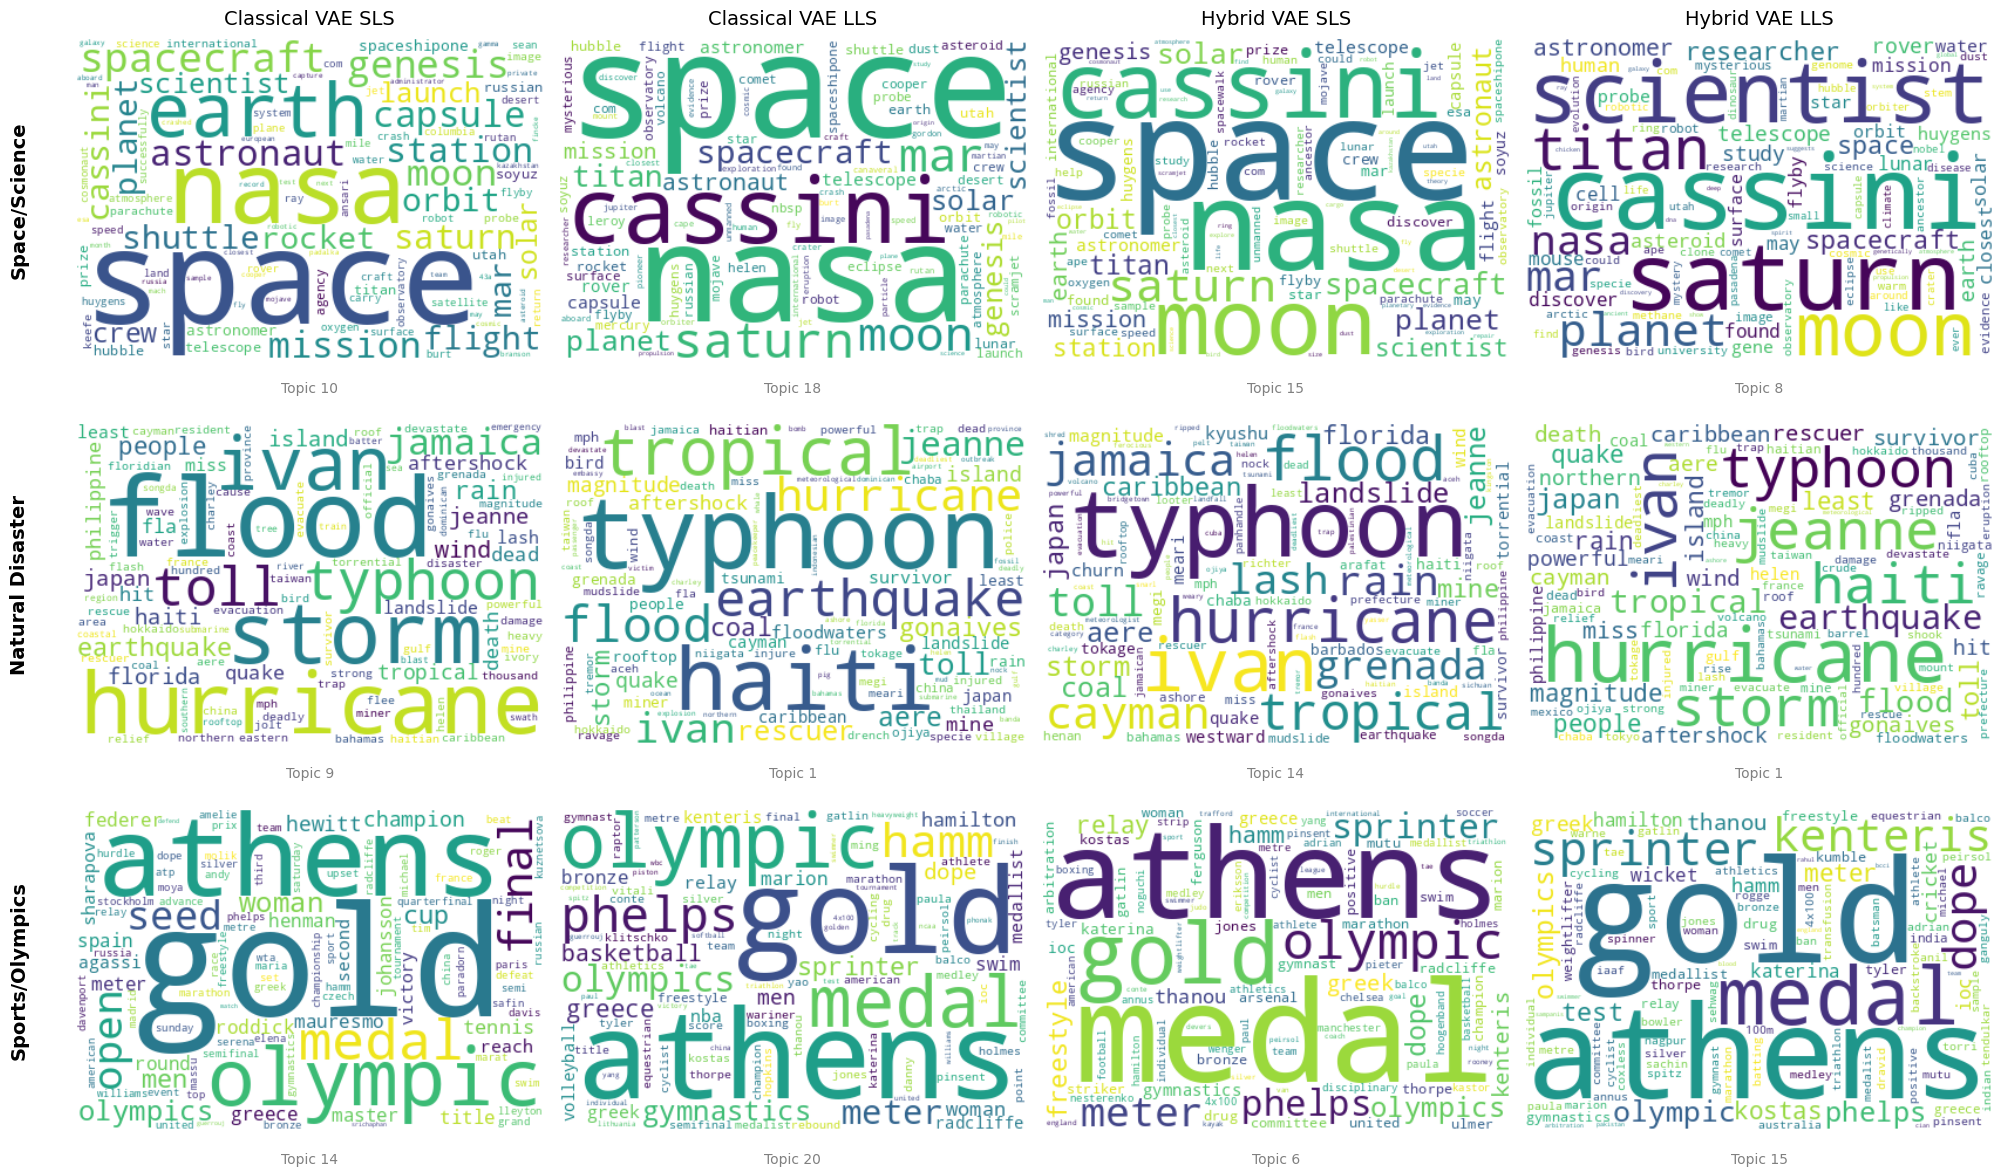

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import torch

def find_topic_by_keywords(topic_word_distributions, vocab_list, keywords):
    scores = []
    for topic_dist in topic_word_distributions:
        top_indices = topic_dist.argsort(descending=True)[:50]
        top_words = [vocab_list[idx] for idx in top_indices]
        score = sum(1 for k in keywords if k in top_words)
        scores.append(score)
    return np.argmax(scores)

model_keys = ["classical vae", "classical vae prob", "hybrid vae", "hybrid vae prob"]
topic_themes = {
    "Space/Science": ["space", "nasa", "cassini", "moon", "saturn", "planet"],
    "Natural Disaster": ["typhoon", "hurricane", "flood", "storm", "ivan"],
    "Sports/Olympics": ["olympic", "gold", "medal", "athens", "phelps"]
}

plot_data = {theme: [] for theme in topic_themes.keys()}

model_display_titles = {
    "classical vae": "Classical VAE SLS",
    "classical vae prob": "Classical VAE LLS",
    "hybrid vae": "Hybrid VAE SLS",
    "hybrid vae prob": "Hybrid VAE LLS"
}

for model_key in model_keys:
    model, vocab_list = load_model(model_classes[model_key], MODELS[model_key])
    topic_dist_all = model.get_topics().cpu()

    for theme, keywords in topic_themes.items():
        idx = find_topic_by_keywords(topic_dist_all, vocab_list, keywords)
        topic_dist = topic_dist_all[idx]

        word_probs = {vocab_list[j]: topic_dist[j].item() for j in range(len(vocab_list))}
        sorted_probs = sorted(word_probs.items(), key=lambda x: x[1], reverse=True)[:100]
        plot_data[theme].append({"words": dict(sorted_probs), "idx": idx, "model": model_key})

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
#fig.suptitle("Top 100 Word Clouds for Semantic Topics Across Models", fontsize=20, y=1.02)

for row_idx, (theme, results) in enumerate(plot_data.items()):
    for col_idx, res in enumerate(results):
        ax = axes[row_idx, col_idx]
        wc = WordCloud(width=400, height=275, background_color='white').generate_from_frequencies(res['words'])
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')

        if row_idx == 0:
            ax.set_title(model_display_titles[res['model']], fontsize=14, pad=10)
        if col_idx == 0:
            ax.text(-0.1, 0.5, theme, transform=ax.transAxes, rotation=90,
                    va='center', ha='right', fontsize=14, fontweight='bold')

        ax.text(0.5, -0.1, f"Topic {res['idx']+1}", transform=ax.transAxes,
                ha='center', fontsize=10, color='gray')

plt.tight_layout()

plt.savefig('word-clouds-agnews.pdf', bbox_inches='tight')
plt.show()